# Olist E-Commerce Dataset Analysis

In [9]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf



# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking

# !pip install tqdm 
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



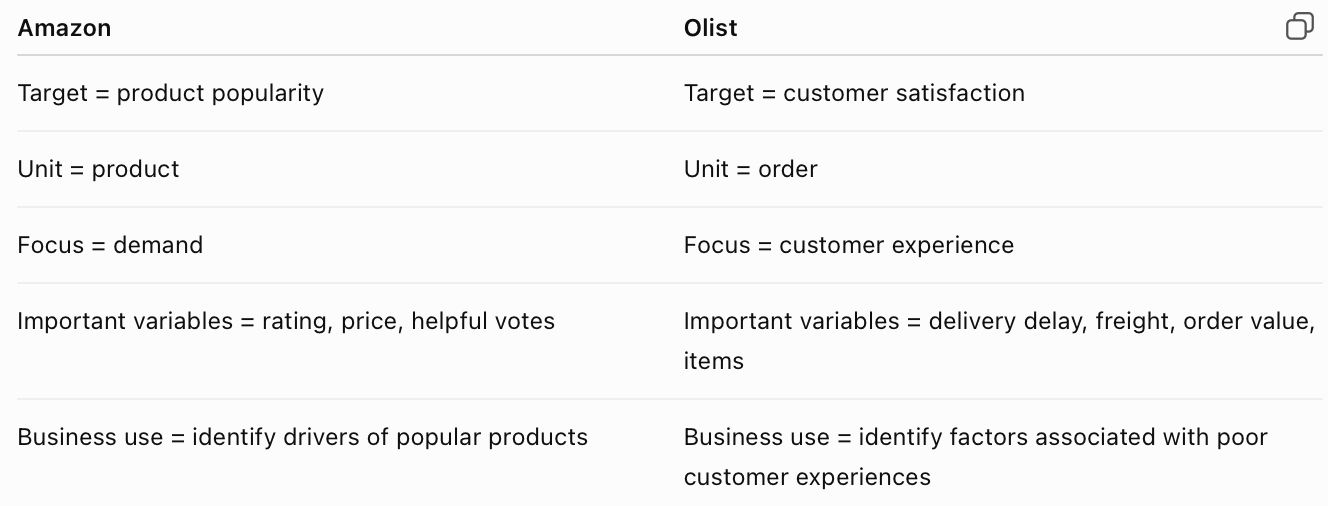
# Olist Dataset Question:
### To what extent can order, payment, and delivery characteristics predict whether an Olist customer leaves a positive review?

## Dataset Loading and Aggregation

In [2]:
#LOAD ALL 9 DATASETS 
customersdf = pd.read_csv('Olist_dataset/olist_customers_dataset.csv')
ordersdf = pd.read_csv('Olist_dataset/olist_orders_dataset.csv')
itemsdf = pd.read_csv('Olist_dataset/olist_order_items_dataset.csv')
paymentsdf = pd.read_csv('Olist_dataset/olist_order_payments_dataset.csv')
reviewsdf = pd.read_csv('Olist_dataset/olist_order_reviews_dataset.csv')
productsdf = pd.read_csv('Olist_dataset/olist_products_dataset.csv')
sellersdf = pd.read_csv('Olist_dataset/olist_sellers_dataset.csv')
geodf = pd.read_csv('Olist_dataset/olist_geolocation_dataset.csv')
translationdf = pd.read_csv('Olist_dataset/product_category_name_translation.csv')


In [3]:
#check column names of all dfs
for name, df in {
    "customers": customersdf,
    "orders": ordersdf,
    "items": itemsdf,
    "payments": paymentsdf,
    "reviews": reviewsdf,
    "products": productsdf,
    "sellers": sellersdf,
    "geo" : geodf,
    "translation" : translationdf
}.items():
    print(name, df.columns)


customers Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
orders Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
items Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
payments Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
reviews Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
products Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qt

In [7]:
#CREATE CENTRAL df -> MERGE on selected dfs (orders, items, products, payments, reviews, customers)

df = ordersdf.merge(itemsdf, on ='order_id')
df = df.merge(productsdf, on='product_id')
df = df.merge(paymentsdf, on='order_id')
df = df.merge(reviewsdf, on='order_id')
df = df.merge(customersdf, on='customer_id')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


## Pre-Processing

In [6]:
# info
olist_df = df.copy() #create copy

olist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  object 
 10  seller_id                      117329 non-null  object 
 11  shipping_limit_date            117329 non-null  object 
 12  price                         

In [12]:
#) check duplicaiton
df.shape # 117329, 36 features
df['order_id'].nunique()    #97916

#how many repeats of same order 
df['order_id'].value_counts().head(10)


order_id
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
465c2e1bee4561cb39e0db8c5993aafc    24
6d58638e32674bebee793a47ac4cbadc    24
c6492b842ac190db807c15aff21a7dd6    24
a3725dfe487d359b5be08cac48b64ec5    24
68986e4324f6a21481df4e6e89abcf01    24
285c2e15bebd4ac83635ccc563dc71f4    22
Name: count, dtype: int64

In [13]:
# Look at most repeated order
top_order = df['order_id'].value_counts().index[0]

df[df['order_id'] == top_order][[
    'order_id',
    'order_item_id',
    'product_id',
    'price',
    'payment_sequential',
    'payment_value',
    'review_id'
]]

,order_id,order_item_id,product_id,price,payment_sequential,payment_value,review_id
84228,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,17,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84229,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,1,2.61,eef5dbca8d37dfce6db7d7b16dd0525e
84230,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,13,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84231,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,16,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84232,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,19,0.24,eef5dbca8d37dfce6db7d7b16dd0525e
...,...,...,...,...,...,...,...
84286,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,15,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84287,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,20,4.61,eef5dbca8d37dfce6db7d7b16dd0525e
84288,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,14,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84289,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,9,2.61,eef5dbca8d37dfce6db7d7b16dd0525e


In [14]:
#NOTE - only 3 order items but x 21 payment records
df[df['order_id'] == top_order][
    ['order_item_id', 'payment_sequential']
].drop_duplicates()

,order_item_id,payment_sequential
84228,1,17
84229,1,1
84230,1,13
84231,1,16
84232,1,19
...,...,...
84286,3,15
84287,3,20
84288,3,14
84289,3,9


## Cleaning up Tables again BEFORE MERGE analysis_df
## Goal = 1 order_id per row

In [16]:
# Order items → one row per order
items_agg = itemsdf.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    num_items=('order_item_id', 'count')
).reset_index()

# Payments → one row per order
payments_agg = paymentsdf.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    num_payments=('payment_sequential', 'count'),
    payment_installments=('payment_installments', 'max')
).reset_index()

display(items_agg.head(), payments_agg.head())

,order_id,total_price,total_freight,num_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


,order_id,total_payment,num_payments,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3


In [21]:
#CREATE ANALYSIS_DF
analysis_df = ordersdf.merge(items_agg, on='order_id', how='left')

analysis_df = analysis_df.merge(
    payments_agg,
    on='order_id',
    how='left'
)

analysis_df = analysis_df.merge(
    reviewsdf,
    on='order_id',
    how='left'
)

analysis_df = analysis_df.merge(
    customersdf,
    on='customer_id',
    how='left'
)


In [22]:
#Display analysis_df
display(
    analysis_df.head(),
    analysis_df.info(),
    analysis_df.shape,
    analysis_df['order_id'].nunique()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   customer_id                    99992 non-null  object 
 2   order_status                   99992 non-null  object 
 3   order_purchase_timestamp       99992 non-null  object 
 4   order_approved_at              99831 non-null  object 
 5   order_delivered_carrier_date   98199 non-null  object 
 6   order_delivered_customer_date  97005 non-null  object 
 7   order_estimated_delivery_date  99992 non-null  object 
 8   total_price                    99214 non-null  float64
 9   total_freight                  99214 non-null  float64
 10  num_items                      99214 non-null  float64
 11  total_payment                  99991 non-null  float64
 12  num_payments                   99991 non-null 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,...,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,...,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


None

(99992, 24)

99441

### ! still duplicates because nunique() doesn't match rows <b>

In [27]:
#NOTE still duplicates in reviewsdf
reviewsdf['order_id'].value_counts().head(10)

order_id
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
5cb890a68b91b6158d69257e4e2bc359    2
2143393cca994a4b8235bc1d67ded772    2
25320e12b3d6e8f54f17389037588bba    2
0176a6846bcb3b0d3aa3116a9a768597    2
d9e44c3fd2ce16086619f299e92e12d8    2
21cb4961399b846b168d0358100f473b    2
Name: count, dtype: int64

In [ ]:
#Aggregate Reviews -> b/c multiple reviews per order_id
reviews_agg = reviewsdf.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()

In [32]:
#final df cleaned
analysis_df = ordersdf.merge(items_agg, on='order_id', how='left')

analysis_df = analysis_df.merge(
    payments_agg,
    on='order_id',
    how='left'
)

analysis_df = analysis_df.merge(
    reviews_agg,
    on='order_id',
    how='left'
)

analysis_df = analysis_df.merge(
    customersdf,
    on='customer_id',
    how='left'
)

#Now all rows = 1 order id
analysis_df['order_id'].nunique()

99441

## --EDA + Feature Engineering Section--

In [35]:
analysis_df.shape # 99441, 19

analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   total_price                    98666 non-null  float64
 9   total_freight                  98666 non-null  float64
 10  num_items                      98666 non-null  float64
 11  total_payment                  99440 non-null  float64
 12  num_payments                   99440 non-null 

In [ ]:
# convert dates to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

#### Create useful features = "delivery_days", "delivery_delay", "late_delivery", "purchase_month", "purchase_dayofweek" 

In [42]:
# Days from purchase → delivery
analysis_df['delivery_days'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_purchase_timestamp']
).dt.days

# Difference between actual and estimated delivery
analysis_df['delivery_delay'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_estimated_delivery_date']
).dt.days

    #delay < 0 = arrived early, >0  = arrived late

#create late_delivery
analysis_df['late_delivery'] = (
    analysis_df['delivery_delay'] > 0
).astype(int)

#purchase-time features
analysis_df['purchase_month'] = (
    analysis_df['order_purchase_timestamp'].dt.month
)

analysis_df['purchase_dayofweek'] = (
    analysis_df['order_purchase_timestamp'].dt.dayofweek
)

np.int64(23)

### Check Statistics

In [44]:
#check statistics 
analysis_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,num_items,total_payment,num_payments,payment_installments,review_score,customer_zip_code_prefix,delivery_days,delivery_delay,late_delivery,purchase_month,purchase_dayofweek
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,99440.000000,98673.000000,99441.000000,96476.000000,96476.000000,99441.000000,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,137.754076,22.823562,1.141731,160.990267,1.044710,2.930521,4.086793,35137.474583,12.094086,-11.876881,0.065717,6.032220,2.755735
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.850000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1003.000000,0.000000,-147.000000,0.000000,1.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,45.900000,13.850000,1.000000,62.010000,1.000000,1.000000,4.000000,11347.000000,6.000000,-17.000000,0.000000,3.000000,1.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,86.900000,17.170000,1.000000,105.290000,1.000000,2.000000,5.000000,24416.000000,10.000000,-12.000000,0.000000,6.000000,3.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,149.900000,24.040000,1.000000,176.970000,1.000000,4.000000,5.000000,58900.000000,15.000000,-7.000000,0.000000,8.000000,4.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1794.960000,21.000000,13664.080000,29.000000,24.000000,5.000000,99990.000000,209.000000,188.000000,1.000000,12.000000,6.000000
std,NaN,NaN,NaN,NaN,NaN,210.645145,21.650909,0.538452,221.951257,0.381166,2.715685,1.346274,29797.938996,9.551746,10.183854,0.247789,3.232999,1.966495


In [45]:
analysis_df['order_status'].value_counts()
    #about 3000 orders not delivered

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [49]:
analysis_df['customer_state'].value_counts().head()
    #most from Sao Paulo

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

In [50]:
analysis_df['review_score'].value_counts().sort_index()

review_score
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64

## CREATE BINARY CLASSIFICATION (positive review = >=4)

In [51]:
# 1 = positive review (4 or higher)
# 0 = negative/neutral review (below 4)
analysis_df['positive_review'] = (
    analysis_df['review_score'] >= 4
).astype(int)

In [52]:
#class balance
analysis_df['positive_review'].value_counts()
analysis_df['positive_review'].value_counts(normalize=True)

positive_review
1    0.764554
0    0.235446
Name: proportion, dtype: float64

### CREATE model_df to use for modeling, analysis_df for EDA
- because missing review scores makes them 0, impacts modeling 

In [53]:
model_df = analysis_df.dropna(subset=['review_score']).copy()

model_df['positive_review'] = (
    model_df['review_score'] >= 4
).astype(int)

## Summary: Olist Order-Level Data Preparation

- Combined Olist order, item, payment, review, and customer data.
- Identified duplicate order IDs caused by one-to-many relationships between orders, items, payments, and reviews.
- Aggregated order items and payments before merging to prevent many-to-many row multiplication.
- Aggregated multiple reviews to one review score per order.
- Created `analysis_df` with one row per unique order (99,441 orders).
- Converted delivery timestamps for subsequent feature engineering.
- Identified a small number of anomalous delivery timestamps for later consideration.
- Created `model_df` for modeling, with no NaN review_score, and `positive_review` target feature ('review_score' >=4)